In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load business master created on Day 1
business = pd.read_csv(r"C:\Users\Rudra\data analytics\Ecommerce_Revenue_Intelligence\data\business_master_cleaned.csv")

business.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,revenue,freight,total_revenue,delivery_days,estimated_days,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,Sao Paulo,Sp,29.99,8.72,38.71,8.0,15,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,Barreiras,Ba,118.70,22.76,141.46,13.0,19,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,Vianopolis,Go,159.90,19.22,179.12,9.0,26,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,Sao Goncalo Do Amarante,Rn,45.00,27.20,72.20,13.0,26,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,Santo Andre,Sp,19.90,8.72,28.62,2.0,12,-10.0


In [3]:
business['order_purchase_timestamp'] = pd.to_datetime(
    business['order_purchase_timestamp']
)

business['order_purchase_timestamp'].head()

0   2017-10-02 10:56:33
1   2018-07-24 20:41:37
2   2018-08-08 08:38:49
3   2017-11-18 19:28:06
4   2018-02-13 21:18:39
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [10]:
#Create Customer Summary
customer_summary = business.groupby('customer_unique_id').agg(
    last_purchase=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('total_revenue', 'sum')
).reset_index()

customer_summary.head()

,customer_unique_id,last_purchase,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [12]:
#Calculate Recency
snapshot_date = business['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

customer_summary['recency'] = (
    snapshot_date - customer_summary['last_purchase']
).dt.days

customer_summary[['customer_unique_id', 'recency', 'frequency', 'monetary']].head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [13]:
customer_summary['R_score'] = pd.qcut(
    customer_summary['recency'],
    4,
    labels=[4, 3, 2, 1]
)

In [14]:
customer_summary['F_score'] = pd.qcut(
    customer_summary['frequency'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
)

In [15]:
customer_summary['M_score'] = pd.qcut(
    customer_summary['monetary'],
    4,
    labels=[1, 2, 3, 4]
)

In [16]:
#Create RFM Score
customer_summary['RFM_score'] = (
    customer_summary['R_score'].astype(str) +
    customer_summary['F_score'].astype(str) +
    customer_summary['M_score'].astype(str)
)

customer_summary[['recency', 'frequency', 'monetary', 'RFM_score']].head()

,recency,frequency,monetary,RFM_score
0,112,1,141.90,413
1,115,1,27.19,311
2,537,1,86.22,112
3,321,1,43.62,211
4,288,1,196.89,214


In [17]:
customer_summary[customer_summary['frequency'] > 1].head()

,customer_unique_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_score
104,004288347e5e88a27ded2bb23747066c,2018-01-14 07:36:54,2,354.37,228,2,4,4,244
243,00a39521eb40f7012db50455bf083460,2018-06-03 10:12:57,2,123.25,88,4,4,3,443
305,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:23,2,126.20,526,1,4,3,143
404,011575986092c30523ecb71ff10cb473,2018-04-18 21:58:08,2,214.90,133,3,4,4,344
419,011b4adcd54683b480c4d841250a987f,2018-02-15 11:40:57,2,236.30,196,3,4,4,344


In [18]:
customer_summary['frequency'].value_counts().sort_index()

frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [19]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

customer_summary['segment'] = customer_summary.apply(segment_customer, axis=1)

customer_summary['segment'].value_counts()

segment
Potential Loyalists    23356
Lost Customers         23323
At Risk                23188
Loyal Customers        21710
Champions               1781
Name: count, dtype: int64

In [20]:
segment_revenue = customer_summary.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    revenue=('monetary', 'sum'),
    avg_value=('monetary', 'mean')
).sort_values('revenue', ascending=False)

segment_revenue

,customers,revenue,avg_value
segment,,,
At Risk,23188,3858397.92,166.396322
Potential Loyalists,23356,3759424.95,160.961849
Lost Customers,23323,3752156.28,160.877944
Loyal Customers,21710,3322917.76,153.059316
Champions,1781,726876.84,408.128490


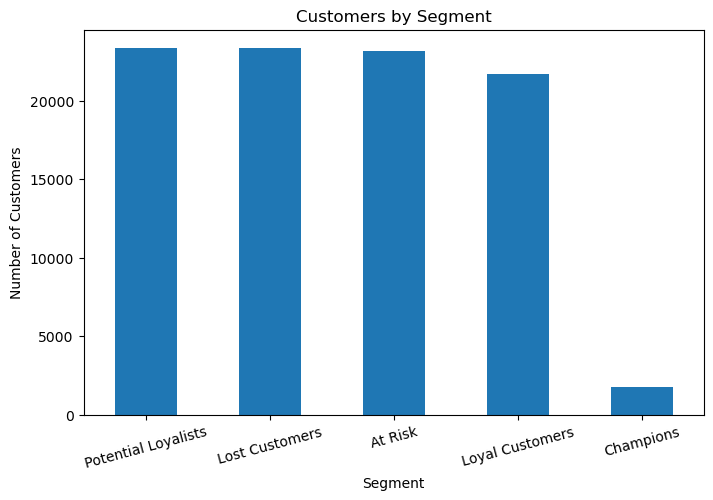

In [21]:
segment_counts = customer_summary['segment'].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')

plt.title('Customers by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

plt.show()

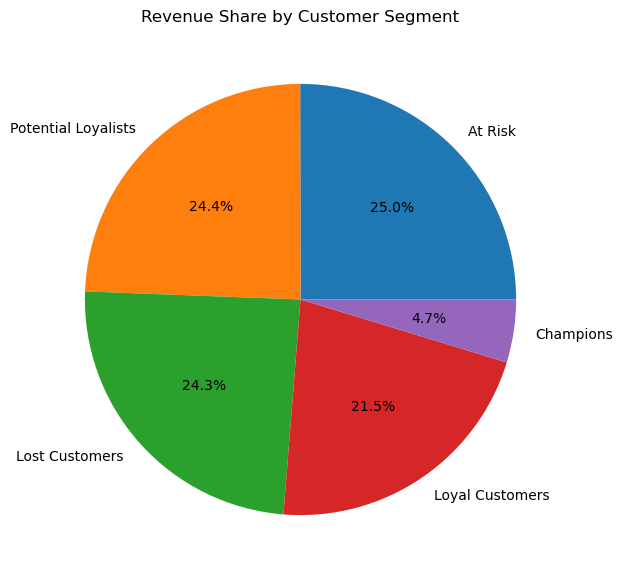

In [22]:
plt.figure(figsize=(7,7))

plt.pie(
    segment_revenue['revenue'],
    labels=segment_revenue.index,
    autopct='%1.1f%%'
)

plt.title('Revenue Share by Customer Segment')

plt.show()

In [23]:
customer_summary.to_csv('../data/customer_rfm_segments.csv', index=False)
segment_revenue.to_csv('../data/segment_revenue_summary.csv')

print('Day 2 files saved!')

Day 2 files saved!
